In [4]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as q

In [14]:
# saving constant
alpha=0.5
N = int(np.ceil(5 * abs(alpha)**2)) + 20      # 40 고정 대신
lim = np.sqrt(2)*abs(alpha) + 5               # 4 고정 대신
T1=0.8
T2=0.8  

In [15]:
a_p=q.coherent(N,alpha) #a_p is positive alpha
a_n=q.coherent(N,-alpha) #a_n is negative alpha
x_vec= p_vec = np.linspace(-lim,lim, 100)
wig_p=q.wigner(a_p,x_vec,p_vec)
wig_n=q.wigner(a_n,x_vec,p_vec)
p_x_p=np.trapezoid(wig_p, p_vec, axis=0)
p_x_n=np.trapezoid(wig_n, p_vec, axis=0)


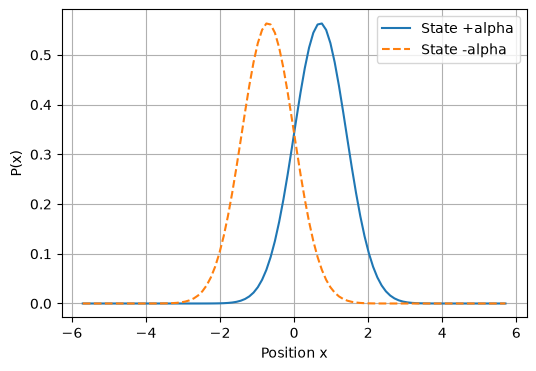

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))

# Plot both datasets on a single axis. Legend added for clarity.
# Accessing .real as an attribute (corrected from .real())
ax.plot(x_vec, p_x_p.real, label='State +alpha', linestyle='-')
ax.plot(x_vec, p_x_n.real, label='State -alpha', linestyle='--')

# Minimal labeling
ax.set_xlabel('Position x')
ax.set_ylabel('P(x)')
ax.grid(True)
ax.legend()

plt.show()

In [17]:
error = 0.5*np.trapezoid(p_x_p[x_vec<0], x_vec[x_vec<0]) + 0.5*np.trapezoid(p_x_n[x_vec>0], x_vec[x_vec>0])

print(error)

0.14026467118219194


In [27]:
from scipy.special import erfc

def error_ho(alpha, pts_per_sigma=20):
    N   = int(np.ceil(5*abs(alpha)**2)) + 20      # truncation ~ 5*n̄
    lim = np.sqrt(2)*abs(alpha) + 5               # 봉우리 √2·alpha 포함
    M   = int(2*lim / (0.707/pts_per_sigma)) | 1  # sigma당 20점, 홀수
    x_vec = p_vec = np.linspace(-lim, lim, M)
    p_x_p = np.trapezoid(q.wigner(q.coherent(N,  alpha), x_vec, p_vec), p_vec, axis=0)
    p_x_n = np.trapezoid(q.wigner(q.coherent(N, -alpha), x_vec, p_vec), p_vec, axis=0)
    assert np.trapezoid(p_x_p, x_vec) > 0.999, f"정규화 깨짐 @ alpha={alpha}"
    return 1 - np.trapezoid(np.maximum(0.5*p_x_p, 0.5*p_x_n), x_vec)

assert abs(error_ho(0.0) - 0.5) < 1e-6, "alpha=0 에서 0.5 아님"   # 필수 검증

a_num = np.linspace(0, 2, 30)                       # 수치 (느림)
e_num = np.array([error_ho(a) for a in a_num])

a_fine = np.linspace(0, 2, 400)                     # 해석해 (빠름)
e_homo = 0.5*erfc(np.sqrt(2)*a_fine)
e_hels = 0.5*(1 - np.sqrt(1 - np.exp(-4*a_fine**2)))

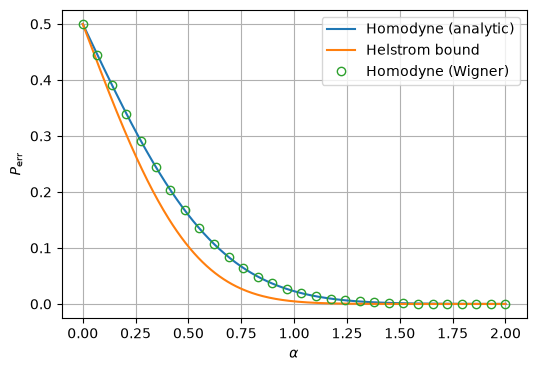

In [29]:
fig, ax = plt.subplots(figsize=(6, 4))

# Plot lines and points
ax.plot(a_fine, e_homo, label='Homodyne (analytic)')
ax.plot(a_fine, e_hels, label='Helstrom bound')
ax.plot(a_num, e_num, 'o', mfc='none', label='Homodyne (Wigner)')

# Minimal labeling (Log scale removed)
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'$P_{\rm err}$')
ax.grid(True)
ax.legend()

plt.show()